In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"

### Load models
Make sure to run `huggingface-cli login` in your terminal first and enter your access token to be able to download the models.

In [2]:
from copy import deepcopy

import torch
import numpy as np
from diffusers.schedulers.scheduling_ddim import DDIMScheduler
import matplotlib.pyplot  as plt

from src.pipeline.bas_pipeline import ControlNetX, StableDiffusionControlNetPipeline, attach_loaders_mixin

DEVICE = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
DTYPE = torch.float16

##### Build-A-Scene
scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", clip_sample=False, set_alpha_to_one=False)
controlnet = ControlNetX.from_pretrained("lllyasviel/control_v11f1p_sd15_depth").to(DEVICE,DTYPE)
pipe = StableDiffusionControlNetPipeline.from_pretrained(
                "stable-diffusion-v1-5/stable-diffusion-v1-5", controlnet=controlnet, requires_safety_checker=False, safety_checker=None,
                torch_dtype=DTYPE, scheduler=scheduler).to(DEVICE)
pipe.controlnet = attach_loaders_mixin(pipe.controlnet)
pipe.controlnet.load_attn_procs("shariqfarooq/loose-control-3dbox")

##### SAM
from transformers import SamModel, SamProcessor
sam_model = SamModel.from_pretrained("facebook/sam-vit-huge").to(DEVICE)
sam_processor = SamProcessor.from_pretrained("facebook/sam-vit-huge")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/datawaha/cggroup/eldesoa/miniconda3/envs/bas/lib/python3.8/site-packages/diffusers/loaders/lora_pipeline.py:2251: FutureWarning: `LoraLoaderMixin` is deprecated and will be removed in version 1.0.0. LoraLoaderMixin is deprecated and this will be removed in a future version. Please use `StableDiffusionLoraLoaderMixin`, instead.
  deprecate("LoraLoaderMixin", "1.0.0", deprecation_message)


### Create an empty scene
The scene is built using `src.utils.scene.DiffusionScene` that creates an empty cube with the size of `scene_size`.

The camera is initialized to look at the cube and the pitch angle can be changed to shift the horizon.

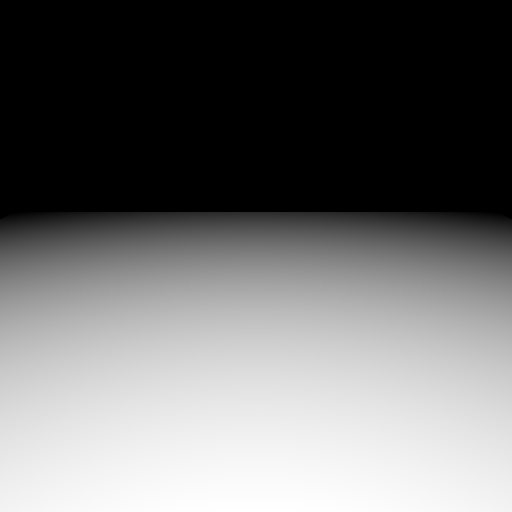

In [3]:
from src.utils.scene import DiffusionScene
from src.utils.visualization import imshowp

# Define scene parameters 
scene_size = 3
cam_pitch_angle = 70
floor_scale_x = 2
floor_scale_y = 2
floor_offset = -1

# Build the scene    
scene = DiffusionScene(scene_size=scene_size)
scene.move_camera(rotation_angle=cam_pitch_angle,rotation_axis=[1,0,0], translation=[0,0,0])
scene.build_floor(scale_x=floor_scale_x, scale_y=floor_scale_y, floor_offset=floor_offset)

# Render the scene with floor
depth_empty = scene.render()

imshowp(depth_empty)

==> Generateing 'An empty city with bricks road in a sunny day' with seed=1343
==> Using 'bas' pipeline! 


  0%|          | 0/40 [00:00<?, ?it/s]

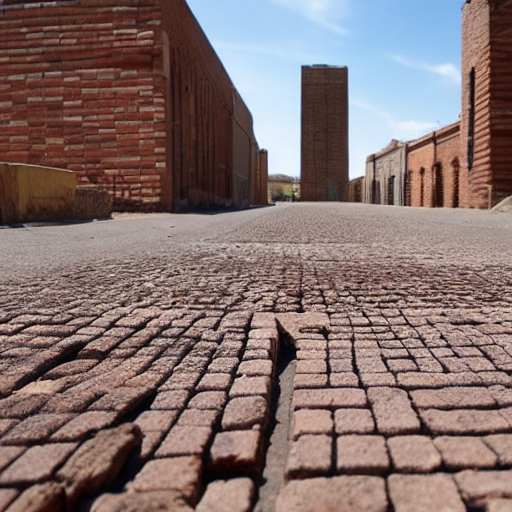

In [4]:
import numpy as np
from PIL import Image

# Generation parameters
NUM_INFER_STEPS = 40
extra_pos_prompts = "" # Optionally add extra positive prompts
neg_prompts = ["blurry, text, caption, lowquality, lowresolution, low-res, grainy, ugly"]

# Define prompt and seed for the empty scene
prompt_empty = "An empty city with bricks road in a sunny day"
init_seed =  1343 #np.random.randint(0, 10000)

# Run the generation
print(f"==> Generateing '{prompt_empty}' with seed={init_seed}")
depth_cond = [Image.fromarray(d) for d in [depth_empty]]
scene.set_pipe(pipe, "bas", NUM_INFER_STEPS, DEVICE, DTYPE, extra_pos_prompts, neg_prompts )
out_img_empty, latents_list_empty = scene.generate(prompts=[prompt_empty], depth_cond=depth_cond, seed=init_seed)
imshowp(out_img_empty[-1])

### Create first object


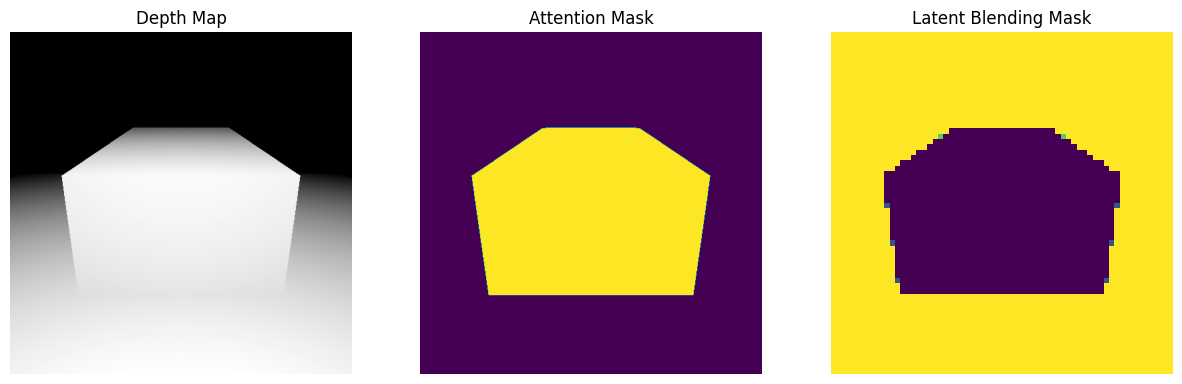

==> Using 'bas' pipeline! 
==> Generateing 'a red mustang car' with seed=9321


  0%|          | 0/40 [00:00<?, ?it/s]

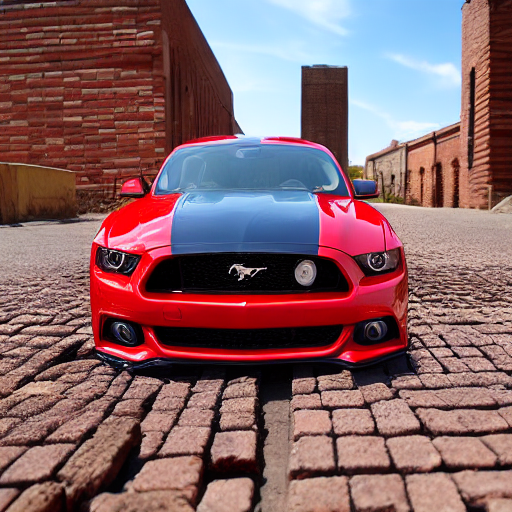

In [ ]:
from src.utils.scene import get_box_renders
from src.utils.visualization import visualize_box_renders

# Add the first box 
new_box_id = "b1"
scene.add_box(id=new_box_id, size=[3.0,6,1.8], origin=[0,1.8,0], prompt="a red mustang car")

b1_seed = 9321 # np.random.randint(0,10000)

## Prepare masks and conditioning signals
depth_b1, attn_mask_b1, latent_mask_b1, prompt_b1, p_img_b1 = get_box_renders(scene, new_box_id, b1_seed)
depth_cond = [Image.fromarray(d) for d in [depth_empty, depth_b1]]
prompts = [prompt_empty, prompt_b1] 
visualize_box_renders(depth_b1, attn_mask_b1, latent_mask_b1)


latent_blending_ratio = 0.1 # [0-1] Higher value improves blending, but can cause artifacts. Tune accordingly
end_latent_blending = int(NUM_INFER_STEPS*latent_blending_ratio)
scene.set_pipe(pipe, "bas", NUM_INFER_STEPS, DEVICE, DTYPE, extra_pos_prompts, neg_prompts)
print(f"==> Generateing '{prompt_b1}' with seed={b1_seed}")
out_imgs_b1, latents_list_b1 = scene.generate( 
                                prompts=prompts, 
                                depth_cond=depth_cond, 
                                seed=b1_seed,
                                attn_mask=attn_mask_b1,
                                latent_mask=latent_mask_b1,                                
                                bg_latents_list=latents_list_empty,
                                blend_latents_timesteps=range(end_latent_blending),
                                mask_dsa_k=True,
                                mask_dsa_v=False, # Enabling this option affects the contrast of the image. Choose accroding to your personal taste
                                use_adain=True,
                                blend_sattn=True, # Optinoally blend features after self-attention
                                )
                                
b1_editor = deepcopy(scene.editor) # Copy the attention editor which stores the attention to be used if needed
imshowp(out_imgs_b1[-1])


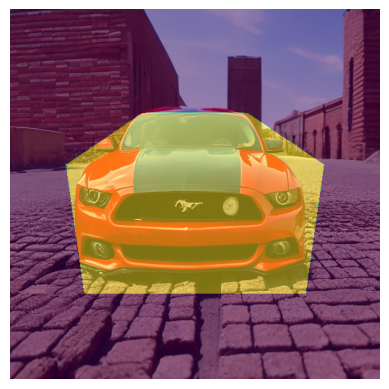

In [6]:
### DEBUG
import torch.nn.functional as F
from src.utils.visualization import imshow
imshow(out_imgs_b1[-1])
imshow(attn_mask_b1, alpha=0.5)

## Move the first object

In [7]:
### Segment the object before first moving 
ref_image = out_imgs_b1[-1]

# Note: the cross-attention segmentation assumes that 'prompt_b1' ends with the object name, e.g. sofa
# modify accordingly if the prompt is different
b1_seg_out = scene.segment_object(sam_processor, sam_model, b1_editor, ref_image, prompt_b1)

In [8]:

from src.utils.segmentation import scale_object_in_image

# Apply the desired move using the actions [move_right, move_left, zoom_in, zoom_out]
ref_box = scene.box(new_box_id)
ref_box.reset()
ref_box.zoom_out(0.8)
ref_box.move_left(1)


# Render the scene again after applying the desired move
depth_b1m = scene.render()
mask_b1m, latent_mask_b1m, p_image_b1m = scene.get_box_masks(box_id=new_box_id)
p_image_b1m = p_image_b1m - scene.box(new_box_id).shift[None, None]

# Warp the object into the new location as described in section 3.3 in the paper
warped_img, scaled_object_b1 = scale_object_in_image(ref_image, object_mask=b1_seg_out["sam_mask"], target_image=out_img_empty[0], 
curr_p_image=p_img_b1, new_p_image=p_image_b1m)

# Invert the pasted image
lat, interm_lats = pipe.invert_depth(Image.fromarray(warped_img), depth=Image.fromarray(depth_b1m), prompt=prompt_b1, num_inference_steps=NUM_INFER_STEPS, device=DEVICE)
# lat, interm_lats = pipe.invert(Image.fromarray(pasted_img), prompt=prompt_new, num_inference_steps=num_infer_steps)


Valid timesteps:  tensor([  0,  25,  50,  75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325,
        350, 375, 400, 425, 450, 475, 500, 525, 550, 575, 600, 625, 650, 675,
        700, 725, 750, 775, 800, 825, 850, 875, 900, 925, 950, 975])


DDIM Inversion:   0%|          | 0/40 [00:00<?, ?it/s]

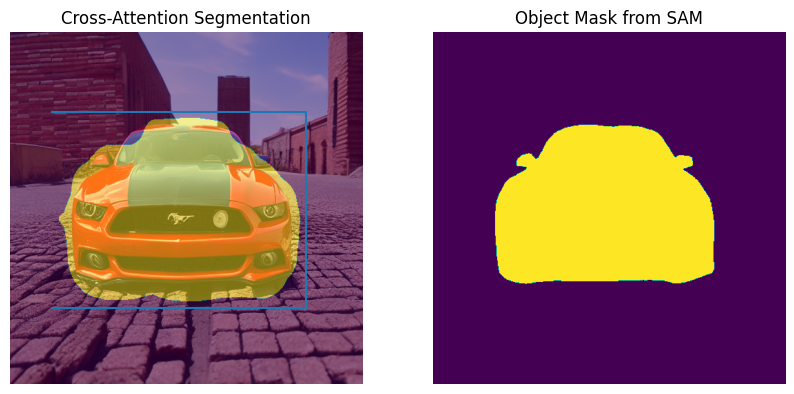

/tmp/ipykernel_1118594/354848293.py:14: RuntimeWarning: invalid value encountered in cast
  imshow(scaled_object_b1.astype(np.uint8), "Scaled Object in the new position")


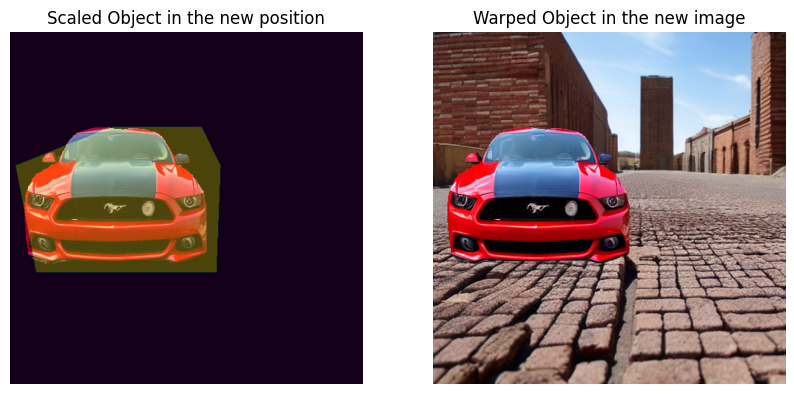

In [9]:
### DEBUG if the object with warped correctly
### Make sure that the object is segmented and warped correctly
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
imshow(ref_image, "Cross-Attention Segmentation")
imshow(b1_seg_out["cn_mask"], alpha=0.5)
x1,y1,x2,y2 = b1_seg_out["sam_box"]
plt.plot([x1,x2,x2,x1],[y1,y1,y2,y2])
plt.subplot(1,2,2)
imshow(b1_seg_out["sam_mask"], "Object Mask from SAM")
plt.show()
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
imshow(scaled_object_b1.astype(np.uint8), "Scaled Object in the new position")
imshow(mask_b1m, alpha=0.3)
plt.subplot(1,2,2)
imshow(warped_img, "Warped Object in the new image")
plt.show()

==> Using 'bas' pipeline! 
==> Generateing 'a red mustang car' with seed=9321


  0%|          | 0/40 [00:00<?, ?it/s]

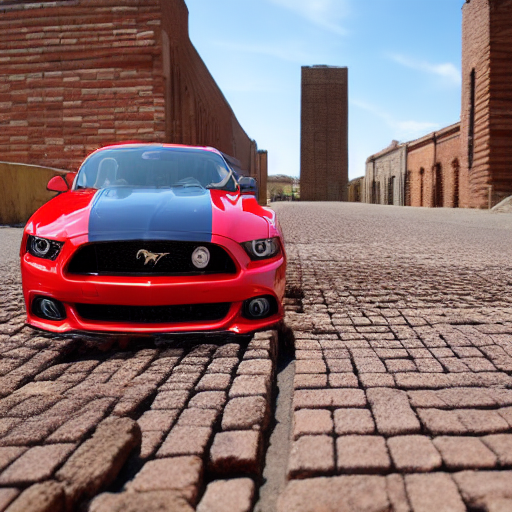

In [10]:
### Depth condition 
depth_cond = [Image.fromarray(d) for d in [depth_empty,depth_b1m]]

new_mask, new_latent_mask = scene.get_attn_latent_masks((scaled_object_b1 > 0)[...,0])
 
latent_blending_ratio = 0.9
end_latent_blending = int(NUM_INFER_STEPS*latent_blending_ratio)
scene.set_pipe(pipe, "bas", NUM_INFER_STEPS, DEVICE, DTYPE, extra_pos_prompts, neg_prompts )
print(f"==> Generateing '{prompt_b1}' with seed={b1_seed}")
out_imgs_b1m, latents_list_b1m = scene.generate(
                                prompts=prompts, 
                                depth_cond=depth_cond, 
                                seed=init_seed,
                                attn_mask=new_mask,
                                latent_mask=new_latent_mask,
                                bg_latents_list=latents_list_empty,
                                blend_latents_timesteps=range(end_latent_blending),
                                fg_latents_list=interm_lats,
                                mask_dsa_k=True,
                                mask_dsa_v=False,
                                use_adain=True,
                                blend_sattn=True
                                )                                

out_imgs_b1m[-1]

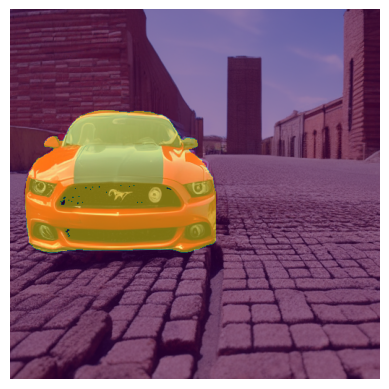

In [14]:
### DEBUG
imshow(out_imgs_b1m[-1])
imshow(new_mask.cpu(), alpha=0.5)

## Add another object

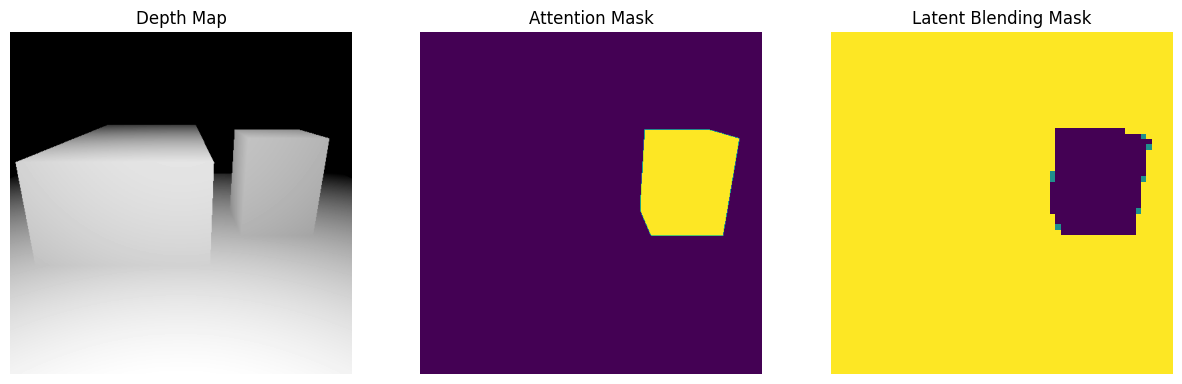

==> Using 'bas' pipeline! 
==> Generateing 'trash can with graffiti' with seed=8178


  0%|          | 0/40 [00:00<?, ?it/s]

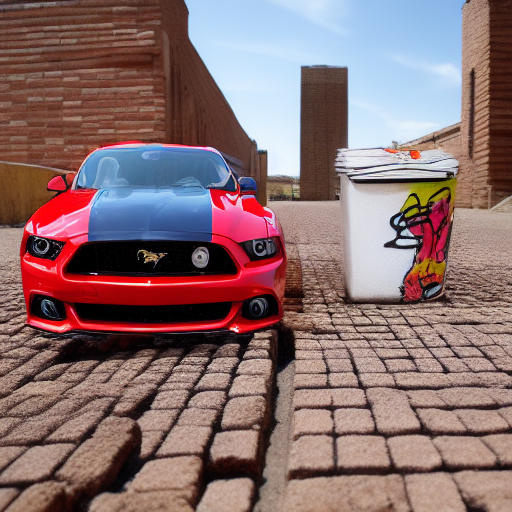

In [12]:
# Add the first box 
new_box_id = "b2"
scene.add_box(id=new_box_id, size=[1.5, 1.5,2.0], origin=[2.0,1.5,0], prompt="trash can with graffiti")

b2_seed = 8178 #np.random.randint(0,10000)# 2293 7254

## Prepare masks and conditioning signals
depth_b2, attn_mask_b2, latent_mask_b2, prompt_b2, p_img_b2 = get_box_renders(scene, new_box_id, b2_seed)
depth_cond = [Image.fromarray(d) for d in [depth_b1m, depth_b2]]
prompts = [prompt_b1, prompt_b2] 
visualize_box_renders(depth_b2, attn_mask_b2, latent_mask_b2)

latent_blending_ratio = 0.9
end_latent_blending = int(NUM_INFER_STEPS*latent_blending_ratio)
scene.set_pipe(pipe, "bas", NUM_INFER_STEPS, DEVICE, DTYPE, extra_pos_prompts, neg_prompts )
print(f"==> Generateing '{prompt_b2}' with seed={b2_seed}")
out_imgs_b2, latents_list_b2 = scene.generate( 
                                prompts=prompts, 
                                depth_cond=depth_cond, 
                                seed=b2_seed,
                                attn_mask=attn_mask_b2,
                                latent_mask=latent_mask_b2,                                
                                bg_latents_list=latents_list_b1m,
                                blend_latents_timesteps=range(end_latent_blending),
                                mask_dsa_k=True,
                                mask_dsa_v=False,
                                use_adain=True
                                )
                                
b2_editor = deepcopy(scene.editor) # Copy the attention editor which stores the attention to be used if needed
# visualize_box_renders(depth_b1, attn_mask_b1, latent_mask_b1)
imshowp(out_imgs_b2[-1])


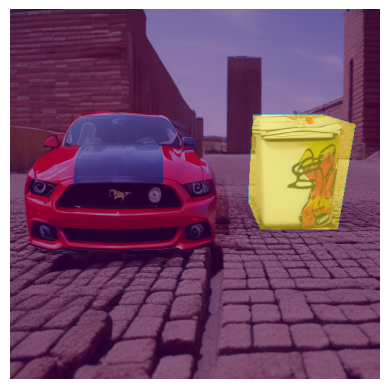

In [13]:
### DEBUG
imshow(out_imgs_b2[-1])
imshow(attn_mask_b2, alpha=0.5)